# 03. TPU에서 분류기 학습과 파인튜닝

이 노트북은 **Colab TPU 런타임에서 실행**합니다. Codespaces에서는 코드를 읽고 수정한 뒤
공식 Colab CLI로 이 파일을 전송합니다. Codespaces의 CPU 커널에서 실행하면 장치 검사에서 멈춥니다.
실행 절차와 의존성 설치 명령은 [Colab CLI 직접 실행 안내](../docs/direct-colab-cli.md)를 따르세요.

오늘 살펴볼 순서는 **라이브러리 가져오기 → 데이터·모델 읽기 → 특징 계산 → head 학습 → 마지막 블록 파인튜닝 → 평가·저장**입니다.
각 단계의 Python 코드를 셀에 그대로 넣었습니다. `vision_lab` 패키지나 통합 실행 함수를 부르지 않습니다.

| 라이브러리 | 이 노트북에서 하는 일 |
|---|---|
| JAX / `jax.numpy` | GPU·TPU 배열 연산, `jit` 컴파일, `value_and_grad` 자동미분 |
| Optax | 교차 엔트로피, Adam 업데이트 |
| NumPy | NPZ 데이터 읽기, 배치 인덱스, 지표 계산, 체크포인트 저장 |
| Pillow (`PIL.Image`) | RGB 변환과 이미지 크기 조정 |
| Safetensors | 사전학습 가중치 읽기 |
| Matplotlib | 학습 곡선과 혼동 행렬 그리기 |

가상환경은 라이브러리 버전을 분리하는 공간입니다. 라이브러리의 역할은 아래 `import`와 사용 코드를 따라 확인할 수 있습니다.

## 라이브러리를 직접 불러오기
가상환경은 라이브러리 버전을 구분하는 공간입니다. 아래 `import`가 이 노트북에서 실제로 사용하는 라이브러리입니다.

| 가져오는 이름 | 설치할 패키지 | 하는 일 |
|---|---|---|
| `numpy` | `numpy` | 이미지 배열, 라벨, `.npz` 파일 |
| `PIL.Image` | `Pillow` | 이미지 읽기와 크기 조절 |
| `matplotlib.pyplot` | `matplotlib` | 이미지와 그래프 표시 |
| `IPython` | `ipykernel`과 함께 설치 | 노트북 안에 그래프 표시 |

`pathlib`, `os`, `sys`, `json`, `hashlib`, `importlib.metadata`는 Python 표준 라이브러리이므로 따로 설치하지 않습니다. 필요한 추가 라이브러리는 사용하는 셀에서 직접 불러옵니다.

In [ ]:
from pathlib import Path
import os
import sys
import json
import hashlib
from importlib.metadata import version

candidates = [Path.cwd(), *Path.cwd().parents, Path("/content/vision-ai")]
ROOT = next((path for path in candidates if (path / ".vision-lab-root").is_file()), None)
if ROOT is None:
    raise RuntimeError(".vision-lab-root가 있는 수업 폴더에서 열거나 Colab에 실습 파일을 먼저 업로드하세요.")
os.chdir(ROOT)
os.environ.setdefault("MPLCONFIGDIR", str(ROOT / ".cache/matplotlib"))
print("Project:", ROOT)
print("Python:", sys.executable)

Project: /content/vision-ai
Python: /usr/bin/python3


In [ ]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from IPython import get_ipython

ipython = get_ipython()
if ipython is not None:
    ipython.run_line_magic("matplotlib", "inline")
plt.rcParams.update({"figure.figsize": (9, 4), "font.size": 11,
                     "axes.spines.top": False, "axes.spines.right": False})
for package in ("numpy", "Pillow", "matplotlib", "ipykernel"):
    print(f"{package}: {version(package)}")

numpy: 2.5.2
Pillow: 12.3.0
matplotlib: 3.11.1


ipykernel: 6.17.1


### JAX와 실행 장치 확인
`jax`는 자동 미분과 컴파일을, `jax.numpy`는 배열 연산을 제공합니다. 설치 패키지는 CPU에서 `jax`, GPU에서 `jax[cuda12]`, TPU에서 `jax[tpu]`입니다. 같은 `import`를 사용하지만 실행 환경에 맞는 패키지가 필요합니다.

GPU·TPU를 요청했는데 장치가 없으면 오류로 중단합니다. CPU로 몰래 바꾸지 않습니다. 강사용 CPU 검증 때만 `VISION_DEVICE=cpu`를 명시할 수 있으며 출력에도 CPU로 기록됩니다.

In [ ]:
import jax
import jax.numpy as jnp

REQUESTED_DEVICE = os.environ.get("VISION_DEVICE", 'tpu')
if REQUESTED_DEVICE not in {"cpu", "gpu", "tpu"}:
    raise ValueError("VISION_DEVICE는 cpu, gpu, tpu 중 하나여야 합니다.")
try:
    devices = jax.devices(REQUESTED_DEVICE)
except RuntimeError as error:
    raise RuntimeError(f"{REQUESTED_DEVICE.upper()}를 찾지 못했습니다. 해당 Colab 런타임에서 실행하세요.") from error
if not devices or devices[0].platform != REQUESTED_DEVICE:
    raise RuntimeError("요청한 장치가 없습니다. Codespaces 자체에는 Colab GPU·TPU가 연결되지 않습니다.")
device = devices[0]
device_info = {"requested": REQUESTED_DEVICE, "platform": device.platform,
               "device_kind": device.device_kind, "available_count": len(devices),
               "used_count": 1, "jax_version": jax.__version__}
print("Device:", device_info)

/usr/local/lib/python3.13/dist-packages/jax/_src/cloud_tpu_init.py:90: UserWarning: Transparent hugepages are not enabled. TPU runtime startup and shutdown time should be significantly improved on TPU v5e and newer. If not already set, you may need to enable transparent hugepages in your VM image (sudo sh -c "echo always > /sys/kernel/mm/transparent_hugepage/enabled")
  warnings.warn(


Device: {'requested': 'tpu', 'platform': 'tpu', 'device_kind': 'TPU v5 lite', 'available_count': 1, 'used_count': 1, 'jax_version': '0.11.1'}


### 모델 계산 1 · 행렬 곱과 정규화
`jnp.matmul`이 가중치와 입력을 곱합니다. LayerNorm은 마지막 축의 평균과 분산으로 값을 정규화합니다.

In [ ]:
def dense(params, prefix, x):
    return jnp.matmul(x, params[prefix + ".weight"].T,
                      precision=jax.lax.Precision.HIGHEST) + params[prefix + ".bias"]

def layer_norm(params, prefix, x, epsilon):
    centered = x - jnp.mean(x, axis=-1, keepdims=True)
    variance = jnp.mean(centered * centered, axis=-1, keepdims=True)
    return centered * jax.lax.rsqrt(variance + epsilon) * params[prefix + ".weight"] + params[prefix + ".bias"]

### 모델 계산 2 · Attention과 Transformer 블록
Query·Key의 내적으로 토큰 사이의 점수를 계산하고 `jax.nn.softmax`로 가중치를 만듭니다. 잔차 연결과 GELU까지 아래 함수에서 확인할 수 있습니다.

In [ ]:
def transformer_block(params, index, x, config):
    prefix = f"vit.encoder.layer.{index}"
    normalized = layer_norm(params, prefix + ".layernorm_before", x, config["layer_norm_eps"])
    batch, tokens, hidden = normalized.shape
    heads = config["num_attention_heads"]
    head_dim = hidden // heads

    def project(name):
        value = dense(params, prefix + ".attention.attention." + name, normalized)
        return value.reshape(batch, tokens, heads, head_dim).transpose(0, 2, 1, 3)

    query, key, value = (project(name) for name in ("query", "key", "value"))
    scores = jnp.matmul(query, key.swapaxes(-1, -2), precision=jax.lax.Precision.HIGHEST)
    probabilities = jax.nn.softmax(scores / jnp.sqrt(jnp.float32(head_dim)), axis=-1)
    context = jnp.matmul(probabilities, value, precision=jax.lax.Precision.HIGHEST)
    context = context.transpose(0, 2, 1, 3).reshape(batch, tokens, hidden)
    x = x + dense(params, prefix + ".attention.output.dense", context)
    normalized = layer_norm(params, prefix + ".layernorm_after", x, config["layer_norm_eps"])
    intermediate = jax.nn.gelu(dense(params, prefix + ".intermediate.dense", normalized), approximate=False)
    return x + dense(params, prefix + ".output.dense", intermediate)

### 모델 계산 3 · 이미지를 패치 토큰으로 바꾸기
224×224 이미지를 16×16 패치로 바꾼 뒤 첫 11개 블록을 통과시킵니다. 이 부분은 추가 학습에서 고정하므로 출력을 캐시할 수 있습니다.

In [ ]:
def prefix_tokens(params, images, config):
    """Patch embedding plus blocks 0..10; this output is safe to cache."""
    if images.ndim != 4 or images.shape[1:] != (224, 224, 3):
        raise ValueError("Expected preprocessed NHWC images [N, 224, 224, 3]")
    x = jax.lax.conv_general_dilated(
        images.astype(jnp.float32),
        params["vit.embeddings.patch_embeddings.projection.weight"].transpose(2, 3, 1, 0),
        window_strides=(config["patch_size"], config["patch_size"]),
        padding="VALID", dimension_numbers=("NHWC", "HWIO", "NHWC"),
        precision=jax.lax.Precision.HIGHEST,
    ) + params["vit.embeddings.patch_embeddings.projection.bias"]
    x = x.reshape(x.shape[0], -1, config["hidden_size"])
    cls = jnp.broadcast_to(params["vit.embeddings.cls_token"], (x.shape[0], 1, config["hidden_size"]))
    x = jnp.concatenate([cls, x], axis=1) + params["vit.embeddings.position_embeddings"]
    for index in range(config["num_hidden_layers"] - 1):
        x = transformer_block(params, index, x, config)
    return x

### 모델 계산 4 · 마지막 블록과 분류기
마지막 블록의 CLS 토큰으로 분류합니다. `original_logits`는 앞서 정의한 함수들을 순서대로 호출해 원본 1,000개 클래스 점수를 계산합니다.

In [ ]:
def tail_features(params, tokens, config):
    x = transformer_block(params, config["num_hidden_layers"] - 1, tokens, config)
    return layer_norm(params, "vit.layernorm", x, config["layer_norm_eps"])[:, 0]

def tail_logits(params, tokens, config):
    return dense(params, "classifier", tail_features(params, tokens, config))

def original_logits(params, images, config):
    return tail_logits(params, prefix_tokens(params, images, config), config)

### 학습할 가중치와 파일 지문
아래 함수는 마지막 블록·LayerNorm·분류기의 이름을 고르고 가중치가 바뀌었는지 확인합니다. `hashlib`의 SHA256은 파일과 배열의 지문을 만드는 표준 라이브러리 함수입니다.

In [ ]:
def is_tail_parameter(name, config):
    return (name.startswith(f"vit.encoder.layer.{config['num_hidden_layers'] - 1}.")
            or name.startswith("vit.layernorm.") or name.startswith("classifier."))

def extract_tail(params, config):
    return {key: value for key, value in params.items() if is_tail_parameter(key, config)}

def initialize_head(class_count, hidden_size, seed=42, device=None):
    if class_count < 2:
        raise ValueError("Fine-tuning requires at least two classes")
    weight = 0.02 * jax.random.normal(jax.random.PRNGKey(seed), (class_count, hidden_size))
    return {"classifier.weight": jax.device_put(weight, device),
            "classifier.bias": jax.device_put(jnp.zeros(class_count, jnp.float32), device)}

def parameter_digest(params):
    digest = hashlib.sha256()
    for key in sorted(params):
        value = np.ascontiguousarray(jax.device_get(params[key]))
        digest.update(key.encode("utf-8"))
        digest.update(str(value.shape).encode("ascii"))
        digest.update(value.dtype.str.encode("ascii"))
        digest.update(value.tobytes())
    return digest.hexdigest()

def file_sha256(path):
    digest = hashlib.sha256()
    with Path(path).open("rb") as stream:
        for block in iter(lambda: stream.read(1024 * 1024), b""):
            digest.update(block)
    return digest.hexdigest()

### 체크포인트 저장과 복원
`np.savez_compressed`와 `np.load`로 갱신한 마지막 블록·분류기를 저장하고 읽습니다. 복원할 때 원본 모델 revision과 각 배열 크기를 검사합니다.

In [ ]:
def save_checkpoint(path, tail, metadata):
    """Store only the adapted final block, norm and head; source stays unchanged."""
    arrays = {key: np.asarray(jax.device_get(value)) for key, value in tail.items()}
    arrays["__metadata__"] = np.array(json.dumps(metadata, ensure_ascii=False))
    np.savez_compressed(path, **arrays)

def load_checkpoint(path, source_params, config, device=None):
    with np.load(path, allow_pickle=False) as archive:
        metadata = json.loads(str(archive["__metadata__"]))
        if metadata.get("model_revision") != MODEL_REVISION:
            raise ValueError("Checkpoint revision does not match the pinned source")
        expected = set(extract_tail(source_params, config))
        actual = set(archive.files) - {"__metadata__"}
        if actual != expected:
            raise ValueError("Checkpoint tail parameter keys do not match the architecture")
        tail = {key: jax.device_put(archive[key], device) for key in actual}
    classes = metadata.get("classes", [])
    for key in expected:
        shape = ((len(classes), config["hidden_size"]) if key == "classifier.weight"
                 else (len(classes),) if key == "classifier.bias" else source_params[key].shape)
        if tail[key].shape != shape:
            raise ValueError(f"Checkpoint parameter shape mismatch: {key}")
    return {**source_params, **tail}, metadata

### safetensors로 사전학습 가중치 읽기
`safetensors.numpy.load_file`은 저장된 텐서를 NumPy 배열로 읽습니다. `jax.device_put`으로 이 배열들을 선택한 장치로 옮깁니다. 새 무작위 모델이 아니라 고정된 DeiT 가중치를 불러옵니다.

In [ ]:
from safetensors.numpy import load_file

MODEL_ID = "facebook/deit-tiny-patch16-224"
MODEL_REVISION = "b3428f18dcc7b543470d07f14b4a4157815d1880"
MODEL_SHA256 = "056550dbe6c439dddb35e1800a48aaef86cfdcf8e566ba73f0d1ce41bc7fa1b3"
ASSETS = ROOT / "assets/pretrained"
config = json.loads((ASSETS / "config.json").read_text(encoding="utf-8"))
if (config["hidden_act"] != "gelu" or config["num_hidden_layers"] != 12
        or config["hidden_size"] != 192 or config["image_size"] != 224
        or config["patch_size"] != 16 or config["num_attention_heads"] != 3):
    raise ValueError("고정된 DeiT tiny 모델 구조와 다릅니다.")
weights_path = ASSETS / "model.safetensors"
if file_sha256(weights_path) != MODEL_SHA256:
    raise ValueError("사전학습 파일 SHA256이 다릅니다.")
numpy_weights = load_file(str(weights_path))
if numpy_weights["classifier.weight"].shape != (1000, 192):
    raise ValueError("원본 1,000개 클래스 분류기가 필요합니다.")
params = {name: jax.device_put(np.asarray(value, np.float32), device)
          for name, value in numpy_weights.items()}
del numpy_weights
print("Model:", MODEL_ID, "revision:", MODEL_REVISION)
print("safetensors:", version("safetensors"), "tensors:", len(params))
for name in ["vit.embeddings.patch_embeddings.projection.weight",
             "vit.encoder.layer.11.attention.attention.query.weight", "classifier.weight"]:
    print(name, params[name].shape, params[name].dtype)

Model: facebook/deit-tiny-patch16-224 revision: b3428f18dcc7b543470d07f14b4a4157815d1880
safetensors: 0.8.0 tensors: 200
vit.embeddings.patch_embeddings.projection.weight (192, 3, 16, 16) float32
vit.encoder.layer.11.attention.attention.query.weight (192, 192) float32
classifier.weight (1000, 192) float32


### Pillow와 NumPy로 입력 전처리
RGB 이미지를 224×224로 바꾸고 픽셀 값을 `(pixel / 255 - 0.5) / 0.5`로 변환합니다. 모델의 `preprocessor_config.json`과 같은 설정입니다. `preprocess`는 외부 패키지가 아닌 아래 셀에서 직접 정의하는 함수입니다.

In [ ]:
def preprocess(images):
    if not len(images):
        return np.empty((0, 224, 224, 3), dtype=np.float32)
    resized = []
    for pixels in images:
        image = Image.fromarray(np.asarray(pixels, dtype=np.uint8)).convert("RGB")
        image = image.resize((224, 224), Image.Resampling.BILINEAR)
        resized.append(np.asarray(image, dtype=np.float32))
    return (np.stack(resized) / np.float32(255) - np.float32(0.5)) / np.float32(0.5)

### 저장된 데이터 읽기와 무결성 확인
`np.load(..., allow_pickle=False)`로 이미지·라벨·ID를 읽습니다. SHA256과 분할별 ID를 검사해 다른 데이터가 섞이거나 손상된 경우 중단합니다. 이 함수의 본문도 아래에 모두 표시합니다.

In [ ]:
def digest(path):
    hasher = hashlib.sha256()
    with Path(path).open("rb") as stream:
        for block in iter(lambda: stream.read(1024 * 1024), b""):
            hasher.update(block)
    return hasher.hexdigest()

In [ ]:
def load_prepared(path):
    path = Path(path)
    manifest = json.loads((path / "manifest.json").read_text(encoding="utf-8"))
    classes = manifest["classes"]
    if len(classes) < 2 or len(set(classes)) != len(classes):
        raise ValueError("클래스 목록이 잘못됐습니다.")
    splits, all_ids = {}, set()
    for name in ("train", "validation", "test"):
        record = manifest["splits"][name]
        if record["file"] != f"{name}.npz":
            raise ValueError("데이터 파일 경로가 예상 형식과 다릅니다.")
        file = path / record["file"]
        if digest(file) != record["sha256"]:
            raise ValueError(f"{name} 데이터 체크섬 불일치")
        with np.load(file, allow_pickle=False) as a:
            images, labels, ids = a["images"], a["labels"], a["ids"].tolist()
        if images.dtype != np.uint8 or images.ndim != 4 or images.shape[-1] != 3:
            raise ValueError("images는 uint8 NHWC RGB여야 합니다.")
        if len(images) != len(labels) or len(ids) != len(labels) or len(labels) != record["count"]:
            raise ValueError("이미지·라벨·식별자 개수가 다릅니다.")
        if labels.ndim != 1 or not np.issubdtype(labels.dtype, np.integer) or len(labels) == 0 or labels.min() < 0 or labels.max() >= len(classes):
            raise ValueError("라벨 범위가 잘못됐습니다.")
        if len(set(ids)) != len(ids) or all_ids.intersection(ids):
            raise ValueError("분할 간 이미지 ID 중복")
        all_ids.update(ids)
        splits[name] = {"images": images, "labels": labels, "ids": ids}
    identity = {k: manifest[k] for k in ("classes", "splits", "seed", "preprocess")}
    if hashlib.sha256(json.dumps(identity, sort_keys=True).encode()).hexdigest() != manifest["dataset_sha256"]:
        raise ValueError("데이터 manifest 지문 불일치")
    return splits, manifest

In [ ]:
DATA_PATH = ROOT / 'data/prepared'
if not (DATA_PATH / "manifest.json").is_file():
    raise RuntimeError("00_setup_and_data.ipynb에서 데이터를 먼저 준비하세요.")
splits, manifest = load_prepared(DATA_PATH)
classes = manifest["classes"]
print("Classes:", classes)
print("Split counts:", {name: len(split["labels"]) for name, split in splits.items()})
print("Dataset fingerprint:", manifest["dataset_sha256"])

Classes: ['bottle', 'bowl', 'can', 'cup', 'plate']
Split counts: {'train': 500, 'validation': 100, 'test': 200}
Dataset fingerprint: f9839f99284c05ef8adda2a5a0b5f7b0548237ebfeff3b9f68bf8faefffe813b


## 1. 학습 조건과 결과 폴더

같은 클래스 순서와 train/validation/test 분할로 진행합니다. 기본값은 head 3 epoch, 파인튜닝 3 epoch,
배치 16, seed 42입니다. 완성된 결과가 있으면 덮어쓰지 않고 멈춥니다.
직접 준비한 데이터는 앞의 `DATA_PATH` 셀을 해당 폴더로 바꿔 읽으세요. 클래스 수와 순서는 manifest를 따릅니다.

In [ ]:
import csv
import time
import optax  # 교차 엔트로피와 Adam 업데이트

SEED = 42
BATCH_SIZE = 16
HEAD_EPOCHS = 3
FINETUNE_EPOCHS = 3
HEAD_LEARNING_RATE = 1e-3
FINETUNE_LEARNING_RATE = 1e-4
if len(classes) < 2:
    raise ValueError("분류할 클래스가 2개 이상 필요합니다.")

# 새 실험을 할 때는 OUTPUT_DIR을 다른 경로로 바꾸세요.
# VISION_OUTPUT_DIR은 강사의 자동 검증에서도 같은 설정을 지정하는 방법입니다.
OUTPUT_DIR = Path(os.environ.get("VISION_OUTPUT_DIR", str(ROOT / "results" / device.platform)))
if (OUTPUT_DIR / "report.json").exists():
    raise FileExistsError(f"완료된 결과가 있습니다. OUTPUT_DIR을 바꾸세요: {OUTPUT_DIR}")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# CPU 검증은 강사가 명시적으로 선택했을 때만 가능합니다.
# 기본 GPU/TPU 수업에서는 데이터를 줄이지 않습니다.
CPU_SMOKE_PER_CLASS = int(os.environ.get("VISION_SMOKE_PER_CLASS", "0"))
if CPU_SMOKE_PER_CLASS < 0:
    raise ValueError("VISION_SMOKE_PER_CLASS는 0 이상이어야 합니다.")
if CPU_SMOKE_PER_CLASS and device.platform != "cpu":
    raise ValueError("작은 데이터 검증은 CPU에서만 허용합니다.")
if CPU_SMOKE_PER_CLASS:
    for name, split in splits.items():
        selected = np.concatenate([
            np.flatnonzero(split["labels"] == label)[:CPU_SMOKE_PER_CLASS]
            for label in range(len(classes))
        ])
        splits[name] = {
            "images": split["images"][selected],
            "labels": split["labels"][selected],
            "ids": [split["ids"][int(index)] for index in selected],
        }
print("실제 장치:", device.platform, "| 결과:", OUTPUT_DIR)
print("분할별 이미지 수:", {name: len(split["labels"]) for name, split in splits.items()})
print("CPU 검증은 GPU·TPU 실습 완료로 인정하지 않습니다." if device.platform == "cpu" else "가속기 실습")

실제 장치: tpu | 결과: /content/vision-ai/results/tpu
분할별 이미지 수: {'train': 500, 'validation': 100, 'test': 200}
가속기 실습


## 2. 배치와 평가 함수

마지막 배치에 이미지가 16장보다 적으면 끝 이미지를 복제해 모양을 맞춥니다.
복제한 행은 `mask=0`으로 표시해 학습 손실에서 제외하고, 평가할 때도 잘라냅니다.

In [ ]:
def batches(values, batch_size, indices=None):
    """마지막 배치도 같은 크기로 만들고, 추가한 행은 mask=0으로 표시합니다."""
    if batch_size < 1 or len(values) < 1:
        raise ValueError("배치와 데이터 크기는 양수여야 합니다.")
    order = np.arange(len(values)) if indices is None else np.asarray(indices)
    for start in range(0, len(order), batch_size):
        actual = order[start:start + batch_size]
        padded = np.pad(actual, (0, batch_size - len(actual)), mode="edge")
        mask = (np.arange(batch_size) < len(actual)).astype(np.float32)
        yield values[padded], padded, mask, len(actual)

배치별 추론 결과에서 패딩 행을 잘라 실제 이미지의 출력만 모읍니다.

In [ ]:
def predict_batches(forward, weights, values):
    outputs = []
    for batch, _, _, count in batches(values, BATCH_SIZE):
        logits = forward(weights, jax.device_put(batch, device))
        outputs.append(np.asarray(jax.device_get(logits))[:count])
    return np.concatenate(outputs)

정확도·macro F1·혼동 행렬을 계산합니다. 클래스 순서는 앞에서 읽은 manifest를 따릅니다.

In [ ]:
def classification_metrics(logits, labels):
    logits = np.asarray(logits, dtype=np.float64)
    labels = np.asarray(labels, dtype=np.int64)
    if len(labels) == 0 or logits.shape != (len(labels), len(classes)):
        raise ValueError("예측과 정답의 크기가 다릅니다.")
    shifted = logits - logits.max(axis=1, keepdims=True)
    log_probs = shifted - np.log(np.exp(shifted).sum(axis=1, keepdims=True))
    predictions = logits.argmax(axis=1)
    confusion = np.zeros((len(classes), len(classes)), dtype=np.int64)
    np.add.at(confusion, (labels, predictions), 1)
    denominator = confusion.sum(axis=0) + confusion.sum(axis=1)
    f1 = np.divide(2 * np.diag(confusion).astype(float), denominator,
                   out=np.zeros(len(classes)), where=denominator != 0)
    return {
        "loss": float(-log_probs[np.arange(len(labels)), labels].mean()),
        "accuracy": float(np.mean(predictions == labels)),
        "macro_f1": float(f1.mean()),
        "count": int(len(labels)),
        "confusion_matrix": confusion.tolist(),
    }

## 3. 학습하지 않는 앞부분의 특징 계산

DeiT의 첫 11개 블록은 고정합니다. 같은 이미지를 넣으면 같은 토큰이 나오므로 한 번만 계산해 둡니다.
head 학습에는 마지막 블록까지 거친 192차원 특징을, 파인튜닝에는 마지막 블록 직전 토큰을 사용합니다.
이 실습에는 데이터 증강이 없습니다.

In [ ]:
# 학습하지 않는 부분: patch embedding + Transformer block 0~10
frozen_prefix = {name: value for name, value in params.items()
                 if not is_tail_parameter(name, config)}
prefix_hash_before = parameter_digest(frozen_prefix)
prefix_forward = jax.jit(lambda weights, pixels: prefix_tokens(weights, pixels, config))
feature_forward = jax.jit(lambda weights, tokens: tail_features(weights, tokens, config))

# 같은 입력에 같은 출력을 내는 부분만 캐시합니다. 데이터 증강은 사용하지 않습니다.
# test에서도 입력 특징만 계산하며, 평가 결과로 모델을 선택하지 않습니다.
cache = {}
for split_name, split in splits.items():
    started = time.perf_counter()
    token_parts = []
    for raw_images, _, _, count in batches(split["images"], BATCH_SIZE):
        pixels = preprocess(raw_images)  # Pillow: RGB/224x224, NumPy: 정규화
        tokens = prefix_forward(params, jax.device_put(pixels, device))
        token_parts.append(np.asarray(jax.device_get(tokens))[:count])
    tokens = np.concatenate(token_parts)
    features = predict_batches(feature_forward, params, tokens)
    cache[split_name] = {
        "tokens": tokens, "features": features,
        "labels": split["labels"], "ids": split["ids"],
    }
    print(f"{split_name}: tokens {tokens.shape}, features {features.shape}, "
          f"{time.perf_counter() - started:.1f}초", flush=True)

train: tokens (500, 197, 192), features (500, 192), 33.3초


validation: tokens (100, 197, 192), features (100, 192), 0.1초


test: tokens (200, 197, 192), features (200, 192), 0.2초


## 4. 원래 모델의 추론 결과 확인

사전학습 모델은 ImageNet의 1000개 클래스를 구분합니다. 아래 출력은 모델이 이미 알고 있는 것을 살펴보는 예시입니다.
이 결과를 물체 5종 분류의 정확도 기준선으로 쓰지는 않습니다. 학습 전후 비교 기준은 다음 단계에서 학습하는 **5종 head**입니다.

In [ ]:
# 원래 1000개 ImageNet 클래스의 추론 결과를 살펴봅니다.
# 이 값은 새 데이터의 클래스 정확도와 비교하는 기준선이 아닙니다.
example_indices = [int(np.flatnonzero(cache["train"]["labels"] == label)[0])
                   for label in range(len(classes))]
original_head = {name: value for name, value in params.items() if name.startswith("classifier.")}
imagenet_logits = dense(original_head, "classifier",
                       jax.device_put(cache["train"]["features"][example_indices], device))
imagenet_probabilities = np.asarray(jax.device_get(jax.nn.softmax(imagenet_logits, axis=-1)))
original_predictions = []
for index, probabilities in zip(example_indices, imagenet_probabilities):
    top5 = probabilities.argsort()[-5:][::-1]
    row = {
        "image_id": str(cache["train"]["ids"][index]),
        "workbench_label": classes[int(cache["train"]["labels"][index])],
        "top5_imagenet": [{"label": config["id2label"][str(int(label))],
                            "probability": float(probabilities[label])} for label in top5],
    }
    original_predictions.append(row)
    print(row["workbench_label"], "→", row["top5_imagenet"][0])

bottle → {'label': 'lotion', 'probability': 0.13245250284671783}
bowl → {'label': 'mortar', 'probability': 0.29710525274276733}
can → {'label': 'whiskey jug', 'probability': 0.03280751779675484}
cup → {'label': 'hourglass', 'probability': 0.09760280698537827}
plate → {'label': 'barometer', 'probability': 0.07974955439567566}


## 5. 새 head와 한 번의 학습 단계

기본 데이터에서는 5개 클래스의 점수(logits)를 내는 head를 만듭니다. 직접 준비한 데이터는 해당 클래스 수에 맞춥니다.
`loss_fn`이 교차 엔트로피를 계산하고,
`jax.value_and_grad`가 손실과 기울기를 구합니다. Optax의 Adam이 가중치 업데이트를 계산합니다.

In [ ]:
# 기존 1000개 클래스 head 대신, manifest의 클래스 수에 맞게 새 head를 만듭니다.
with jax.default_device(device):
    head = {
        "classifier.weight": 0.02 * jax.random.normal(
            jax.random.PRNGKey(SEED), (len(classes), config["hidden_size"])),
        "classifier.bias": jnp.zeros(len(classes), dtype=jnp.float32),
    }
head_optimizer = optax.adam(HEAD_LEARNING_RATE)
head_optimizer_state = head_optimizer.init(head)
head_forward = jax.jit(lambda weights, features: dense(weights, "classifier", features))


@jax.jit
def head_step(weights, optimizer_state, features, labels, mask):
    def loss_fn(candidate_weights):
        logits = dense(candidate_weights, "classifier", features)
        per_image_loss = optax.softmax_cross_entropy_with_integer_labels(logits, labels)
        # 패딩 행을 제외한 실제 이미지 수로 나눕니다.
        return jnp.sum(per_image_loss * mask) / jnp.sum(mask)

    loss, gradients = jax.value_and_grad(loss_fn)(weights)
    updates, optimizer_state = head_optimizer.update(gradients, optimizer_state, weights)
    weights = optax.apply_updates(weights, updates)
    return weights, optimizer_state, loss

print("head에서 학습할 가중치 수:", sum(value.size for value in head.values()))

head에서 학습할 가중치 수: 965


## 6. head 학습 반복문

epoch마다 train 순서를 섞고 head만 업데이트합니다. **validation 손실이 가장 낮은 epoch**를 선택합니다.
이 반복문에는 test 평가가 없습니다.

In [ ]:
head_rows = []
best_head = None
best_head_loss = float("inf")
best_head_epoch = None
head_rng = np.random.default_rng(SEED)

for epoch in range(1, HEAD_EPOCHS + 1):
    started = time.perf_counter()
    order = head_rng.permutation(len(cache["train"]["labels"]))
    total_loss = 0.0
    for features, indices, mask, count in batches(cache["train"]["features"], BATCH_SIZE, order):
        head, head_optimizer_state, loss = head_step(
            head, head_optimizer_state,
            jax.device_put(features, device),
            jax.device_put(cache["train"]["labels"][indices], device),
            jax.device_put(mask, device),
        )
        total_loss += float(loss) * count

    validation_logits = predict_batches(head_forward, head, cache["validation"]["features"])
    validation_metrics = classification_metrics(validation_logits, cache["validation"]["labels"])
    if not np.isfinite(total_loss) or not np.isfinite(validation_metrics["loss"]):
        raise FloatingPointError("head 학습 손실이 유한한 값이 아닙니다.")
    if validation_metrics["loss"] < best_head_loss:
        best_head_loss = validation_metrics["loss"]
        best_head_epoch = epoch
        best_head = dict(head)  # JAX 배열은 불변이므로 이후 업데이트가 이 값을 바꾸지 않습니다.

    row = {
        "stage": "head", "epoch": epoch,
        "train_loss": total_loss / len(cache["train"]["labels"]),
        "validation_loss": validation_metrics["loss"],
        "validation_accuracy": validation_metrics["accuracy"],
        "elapsed_seconds": time.perf_counter() - started,
    }
    head_rows.append(row)
    print(f"head {epoch}/{HEAD_EPOCHS}: train loss {row['train_loss']:.4f}, "
          f"validation loss {row['validation_loss']:.4f}, "
          f"accuracy {row['validation_accuracy']:.3f}", flush=True)

head_info = {
    "best_epoch": best_head_epoch, "validation_loss": best_head_loss,
    "selection_rule": "lowest validation cross entropy after each epoch",
}
print("검증 손실로 선택한 head epoch:", best_head_epoch)

head 1/3: train loss 1.2426, validation loss 0.8989, accuracy 0.750


head 2/3: train loss 0.7617, validation loss 0.6670, accuracy 0.830


head 3/3: train loss 0.5990, validation loss 0.5891, accuracy 0.850


검증 손실로 선택한 head epoch: 3


## 7. 마지막 블록까지 학습하도록 범위 변경

이제 학습된 head와 함께 마지막 Transformer 블록, 최종 LayerNorm도 업데이트합니다.
기본 5개 클래스의 학습 대상은 총 **446,213개 가중치**입니다. 직접 준비한 데이터는 클래스 수에 따라 head 크기가 달라집니다.
학습률은 `1e-4`이며 앞의 11개 블록은 계속 고정합니다.

In [ ]:
# 마지막 Transformer block + 최종 LayerNorm + 학습된 head만 업데이트합니다.
baseline_tail = {**extract_tail(params, config), **best_head}
tuned_tail = dict(baseline_tail)
trainable_count = sum(int(value.size) for value in tuned_tail.values())
backbone_tail_count = sum(int(value.size) for name, value in baseline_tail.items()
                          if not name.startswith("classifier."))
expected_trainable_count = backbone_tail_count + len(classes) * (config["hidden_size"] + 1)
if trainable_count != expected_trainable_count:
    raise ValueError("마지막 블록·LayerNorm·head의 가중치 수가 맞지 않습니다.")

finetune_optimizer = optax.adam(FINETUNE_LEARNING_RATE)
finetune_optimizer_state = finetune_optimizer.init(tuned_tail)
finetune_forward = jax.jit(lambda weights, tokens: tail_logits(weights, tokens, config))


@jax.jit
def finetune_step(weights, optimizer_state, tokens, labels, mask):
    def loss_fn(candidate_weights):
        logits = tail_logits(candidate_weights, tokens, config)
        per_image_loss = optax.softmax_cross_entropy_with_integer_labels(logits, labels)
        return jnp.sum(per_image_loss * mask) / jnp.sum(mask)

    loss, gradients = jax.value_and_grad(loss_fn)(weights)
    updates, optimizer_state = finetune_optimizer.update(gradients, optimizer_state, weights)
    weights = optax.apply_updates(weights, updates)
    return weights, optimizer_state, loss

print("파인튜닝할 가중치 수:", trainable_count)
print("고정할 가중치 수:", sum(value.size for value in frozen_prefix.values()))

파인튜닝할 가중치 수: 446213
고정할 가중치 수: 5079168


## 8. 파인튜닝 반복문

이번에는 캐시한 토큰을 마지막 블록에 넣습니다. head와 마찬가지로 validation 손실만 보고 epoch를 선택합니다.
검증 결과가 좋지 않더라도 test 결과를 보고 학습 횟수를 다시 고르지 않습니다.

In [ ]:
finetune_rows = []
best_tuned_tail = None
best_finetune_loss = float("inf")
best_finetune_epoch = None
finetune_rng = np.random.default_rng(SEED + 1)

for epoch in range(1, FINETUNE_EPOCHS + 1):
    started = time.perf_counter()
    order = finetune_rng.permutation(len(cache["train"]["labels"]))
    total_loss = 0.0
    for tokens, indices, mask, count in batches(cache["train"]["tokens"], BATCH_SIZE, order):
        tuned_tail, finetune_optimizer_state, loss = finetune_step(
            tuned_tail, finetune_optimizer_state,
            jax.device_put(tokens, device),
            jax.device_put(cache["train"]["labels"][indices], device),
            jax.device_put(mask, device),
        )
        total_loss += float(loss) * count

    validation_logits = predict_batches(finetune_forward, tuned_tail, cache["validation"]["tokens"])
    validation_metrics = classification_metrics(validation_logits, cache["validation"]["labels"])
    if not np.isfinite(total_loss) or not np.isfinite(validation_metrics["loss"]):
        raise FloatingPointError("파인튜닝 손실이 유한한 값이 아닙니다.")
    if validation_metrics["loss"] < best_finetune_loss:
        best_finetune_loss = validation_metrics["loss"]
        best_finetune_epoch = epoch
        best_tuned_tail = dict(tuned_tail)

    row = {
        "stage": "finetune", "epoch": epoch,
        "train_loss": total_loss / len(cache["train"]["labels"]),
        "validation_loss": validation_metrics["loss"],
        "validation_accuracy": validation_metrics["accuracy"],
        "elapsed_seconds": time.perf_counter() - started,
    }
    finetune_rows.append(row)
    print(f"finetune {epoch}/{FINETUNE_EPOCHS}: train loss {row['train_loss']:.4f}, "
          f"validation loss {row['validation_loss']:.4f}, "
          f"accuracy {row['validation_accuracy']:.3f}", flush=True)

finetune_info = {
    "best_epoch": best_finetune_epoch, "validation_loss": best_finetune_loss,
    "selection_rule": "lowest validation cross entropy after each epoch",
}
print("검증 손실로 선택한 파인튜닝 epoch:", best_finetune_epoch)

finetune 1/3: train loss 0.4696, validation loss 0.4830, accuracy 0.850


finetune 2/3: train loss 0.3564, validation loss 0.4810, accuracy 0.840


finetune 3/3: train loss 0.2986, validation loss 0.4638, accuracy 0.830


검증 손실로 선택한 파인튜닝 epoch: 3


## 9. 같은 test 분할로 평가

선택을 마친 두 모델을 비교합니다. 파인튜닝으로 정확도가 반드시 높아지는 것은 아닙니다.
정확도와 macro F1을 확인하고, 고정 가중치는 그대로인지, 마지막 블록 가중치는 바뀌었는지도 검사합니다.

In [ ]:
# 모델 선택이 모두 끝난 뒤, 같은 test 이미지로 두 모델을 평가합니다.
head_test_logits = predict_batches(head_forward, best_head, cache["test"]["features"])
finetune_test_logits = predict_batches(finetune_forward, best_tuned_tail, cache["test"]["tokens"])
head_info["test"] = classification_metrics(head_test_logits, cache["test"]["labels"])
finetune_info["test"] = classification_metrics(finetune_test_logits, cache["test"]["labels"])

# 첫 11개 블록이 그대로인지, 마지막 블록은 실제로 바뀌었는지 검사합니다.
merged_params = {**params, **best_tuned_tail}
prefix_after = {name: value for name, value in merged_params.items()
                if not is_tail_parameter(name, config)}
prefix_hash_after = parameter_digest(prefix_after)
last_block_prefix = f"vit.encoder.layer.{config['num_hidden_layers'] - 1}."
last_block_delta_l2 = float(np.sqrt(sum(
    np.sum(np.square(np.asarray(jax.device_get(best_tuned_tail[name]))
                     - np.asarray(jax.device_get(value))), dtype=np.float64)
    for name, value in params.items() if name.startswith(last_block_prefix)
)))
if prefix_hash_before != prefix_hash_after:
    raise RuntimeError("고정해야 할 앞부분의 가중치가 바뀌었습니다.")
if not np.isfinite(last_block_delta_l2) or last_block_delta_l2 <= 0:
    raise RuntimeError("마지막 블록의 가중치가 갱신되지 않았습니다.")

for name, info in [("head 학습 후", head_info), ("마지막 블록 파인튜닝 후", finetune_info)]:
    print(f"{name}: test accuracy {info['test']['accuracy']:.1%}, "
          f"macro F1 {info['test']['macro_f1']:.4f}")
print("고정 가중치 동일:", prefix_hash_before == prefix_hash_after)
print("마지막 블록의 변화량 L2:", last_block_delta_l2)

head 학습 후: test accuracy 79.0%, macro F1 0.7873
마지막 블록 파인튜닝 후: test accuracy 82.0%, macro F1 0.8204
고정 가중치 동일: True
마지막 블록의 변화량 L2: 1.144053107217442


## 10. 어느 물체를 혼동하는지 확인

혼동 행렬의 행은 정답, 열은 예측입니다. 같은 test 이미지에서 head 학습 후와 파인튜닝 후를 비교합니다.
아래 학습 곡선은 모델을 선택할 때 사용한 train/validation 손실입니다.

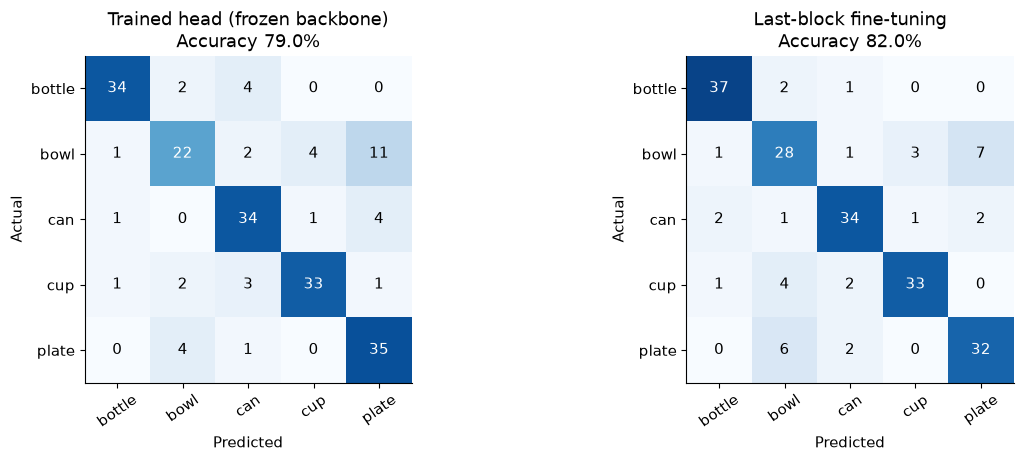

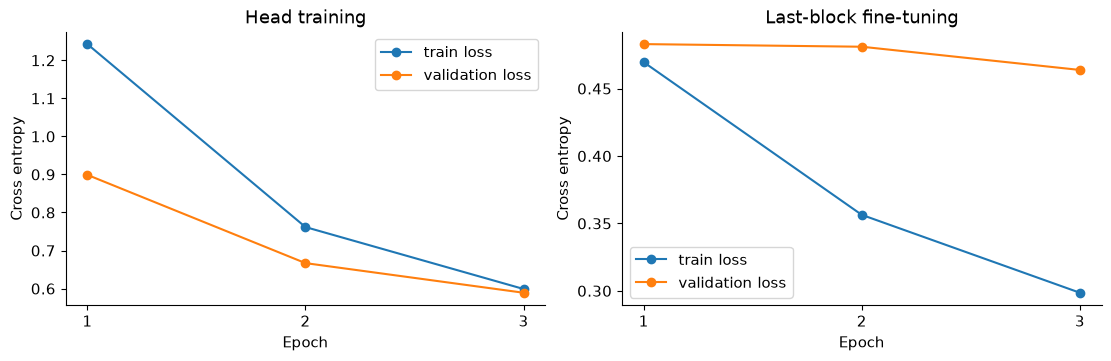

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True)
for axis, title, info in zip(axes, ["Trained head (frozen backbone)", "Last-block fine-tuning"],
                           [head_info, finetune_info]):
    confusion = np.asarray(info["test"]["confusion_matrix"])
    axis.imshow(confusion, cmap="Blues", vmin=0, vmax=max(1, confusion.sum(axis=1).max()))
    for row in range(len(classes)):
        for column in range(len(classes)):
            axis.text(column, row, str(confusion[row, column]), ha="center", va="center",
                      color="white" if confusion[row, column] > confusion.sum(axis=1).max() / 2 else "black")
    axis.set(xticks=range(len(classes)), yticks=range(len(classes)),
             xticklabels=classes, yticklabels=classes,
             xlabel="Predicted", ylabel="Actual", title=f"{title}\nAccuracy {info['test']['accuracy']:.1%}")
    axis.tick_params(axis="x", rotation=35)
fig.savefig(OUTPUT_DIR / "confusion_comparison.png", dpi=150)
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5), constrained_layout=True)
for axis, title, rows in zip(axes, ["Head training", "Last-block fine-tuning"],
                           [head_rows, finetune_rows]):
    epochs = [row["epoch"] for row in rows]
    axis.plot(epochs, [row["train_loss"] for row in rows], "o-", label="train loss")
    axis.plot(epochs, [row["validation_loss"] for row in rows], "o-", label="validation loss")
    axis.set(title=title, xlabel="Epoch", ylabel="Cross entropy", xticks=epochs)
    axis.legend()
fig.savefig(OUTPUT_DIR / "learning_curves.png", dpi=150)
plt.show()

## 11. 결과 저장

`np.savez_compressed`로 마지막 블록·LayerNorm·head와 클래스 순서를 저장합니다.
`csv`는 학습 이력과 개별 예측을, `json`은 실험 조건과 검사 결과를 기록합니다.
사전학습 원본 파일은 그대로 두고 학습한 부분만 저장합니다.

In [ ]:
weights_sha256 = file_sha256(ROOT / "assets/pretrained/model.safetensors")
manifest_sha256 = file_sha256(DATA_PATH / "manifest.json")
checkpoint_metadata = {
    "model_id": MODEL_ID, "model_revision": MODEL_REVISION,
    "weights_sha256": weights_sha256, "classes": classes,
    "manifest_sha256": manifest_sha256,
    "preprocessing": "pinned preprocessor_config.json; RGB NHWC 224x224 float32",
}

# np.savez_compressed: 학습한 마지막 부분과 클래스 순서를 함께 저장합니다.
# head_checkpoint에도 마지막 블록을 넣어 추론할 때 복원 형식을 맞춥니다.
for filename, stage, selected_weights in [
    ("head_checkpoint.npz", "head", baseline_tail),
    ("finetuned_checkpoint.npz", "finetune", best_tuned_tail),
]:
    arrays = {name: np.asarray(jax.device_get(value)) for name, value in selected_weights.items()}
    arrays["__metadata__"] = np.array(json.dumps({**checkpoint_metadata, "stage": stage}, ensure_ascii=False))
    np.savez_compressed(OUTPUT_DIR / filename, **arrays)

학습 이력과 개별 이미지의 예측을 CSV로 저장합니다.

In [ ]:
with (OUTPUT_DIR / "training.csv").open("w", newline="", encoding="utf-8") as stream:
    writer = csv.DictWriter(stream, fieldnames=["stage", "epoch", "train_loss", "validation_loss",
                                               "validation_accuracy", "elapsed_seconds"])
    writer.writeheader()
    writer.writerows(head_rows + finetune_rows)

head_probabilities = np.asarray(jax.nn.softmax(head_test_logits, axis=-1))
finetune_probabilities = np.asarray(jax.nn.softmax(finetune_test_logits, axis=-1))
prediction_rows = []
for index, true_label in enumerate(cache["test"]["labels"]):
    before = int(head_test_logits[index].argmax())
    after = int(finetune_test_logits[index].argmax())
    prediction_rows.append({
        "image_id": str(cache["test"]["ids"][index]), "true_label": classes[int(true_label)],
        "head_prediction": classes[before], "finetune_prediction": classes[after],
        "head_confidence": float(head_probabilities[index, before]),
        "finetune_confidence": float(finetune_probabilities[index, after]),
    })
with (OUTPUT_DIR / "predictions.csv").open("w", newline="", encoding="utf-8") as stream:
    writer = csv.DictWriter(stream, fieldnames=list(prediction_rows[0]))
    writer.writeheader()
    writer.writerows(prediction_rows)

for name, info in [("head", head_info), ("finetune", finetune_info)]:
    with (OUTPUT_DIR / f"confusion_{name}.csv").open("w", newline="", encoding="utf-8") as stream:
        writer = csv.writer(stream)
        writer.writerow(["true/predicted"] + classes)
        writer.writerows([[label] + row for label, row in zip(classes, info["test"]["confusion_matrix"])])

(OUTPUT_DIR / "original_predictions.json").write_text(
    json.dumps(original_predictions, ensure_ascii=False, indent=2), encoding="utf-8")
print("모델·학습 이력·예측을 저장했습니다:", OUTPUT_DIR)

모델·학습 이력·예측을 저장했습니다: /content/vision-ai/results/tpu


보고서에는 모델·데이터·학습 조건과 실제 장치를 함께 기록합니다.

In [ ]:
# 실행 상태를 JSON으로 남깁니다. CLI 종료 코드만으로 성공을 판단하지 않습니다.
accelerator_verified = device.platform in {"gpu", "tpu"}
report = {
    "schema_version": 2,
    "status": "completed" if accelerator_verified else ("cpu_smoke_only" if CPU_SMOKE_PER_CLASS else "cpu_validation"),
    "pipeline_completed": True,
    "accelerator_verified": accelerator_verified,
    "classes": classes,
    "model": {"id": MODEL_ID, "revision": MODEL_REVISION, "weights_sha256": weights_sha256},
    "dataset": {
        "manifest_sha256": manifest_sha256, "classes": classes,
        "split_counts": {name: len(split["labels"]) for name, split in splits.items()},
        "source": manifest.get("source"),
        "split_ids": {name: [str(value) for value in split["ids"]] for name, split in splits.items()},
    },
    "config": {
        "seed": SEED, "head_epochs": HEAD_EPOCHS, "finetune_epochs": FINETUNE_EPOCHS,
        "batch_size": BATCH_SIZE, "learning_rate": FINETUNE_LEARNING_RATE,
        "head_learning_rate": HEAD_LEARNING_RATE, "cpu_smoke_per_class": CPU_SMOKE_PER_CLASS,
        "dtype": "float32", "optimizer": "Adam",
        "augmentation": "none: deterministic frozen-prefix cache",
        "checkpoint_selection": "validation_loss_only",
    },
    "device": device_info,
    "stages": {"head": head_info, "finetune": finetune_info},
    "verification": {
        "frozen_prefix_sha256_before": prefix_hash_before,
        "frozen_prefix_sha256_after": prefix_hash_after,
        "frozen_prefix_unchanged": prefix_hash_before == prefix_hash_after,
        "last_block_delta_l2": last_block_delta_l2,
        "last_block_changed": last_block_delta_l2 > 0,
        "trainable_parameter_count": trainable_count,
        "frozen_parameter_count": sum(int(value.size) for value in frozen_prefix.values()),
    },
    "artifacts": {
        "head_checkpoint": "head_checkpoint.npz", "finetuned_checkpoint": "finetuned_checkpoint.npz",
        "training": "training.csv", "predictions": "predictions.csv",
        "original_predictions": "original_predictions.json",
        "confusion_head": "confusion_head.csv", "confusion_finetune": "confusion_finetune.csv",
        "confusion_plot": "confusion_comparison.png", "learning_curves": "learning_curves.png",
    },
    "interpretation": "Compare the trained frozen-backbone head with last-block fine-tuning on the same held-out test split. "
                      "Original ImageNet predictions are qualitative, not a target-class baseline. "
                      "Fine-tuning is not guaranteed to improve accuracy.",
}

체크포인트와 결과 파일을 다시 확인한 뒤 완료 보고서를 저장합니다.

In [ ]:
# 저장한 체크포인트의 형식과 메타데이터도 확인합니다.
for filename in ["head_checkpoint.npz", "finetuned_checkpoint.npz"]:
    with np.load(OUTPUT_DIR / filename, allow_pickle=False) as archive:
        restored_metadata = json.loads(str(archive["__metadata__"]))
        assert restored_metadata["classes"] == classes
        assert restored_metadata["weights_sha256"] == weights_sha256
        assert archive["classifier.weight"].shape == (len(classes), config["hidden_size"])
        assert set(archive.files) - {"__metadata__"} == set(best_tuned_tail)
        assert all(np.all(np.isfinite(archive[name])) for name in best_tuned_tail)
for relative_path in report["artifacts"].values():
    path = OUTPUT_DIR / relative_path
    assert path.is_file() and path.stat().st_size > 0, path

report["artifact_sha256"] = {
    relative_path: file_sha256(OUTPUT_DIR / relative_path)
    for relative_path in report["artifacts"].values()
}
(OUTPUT_DIR / "report.json").write_text(json.dumps(report, ensure_ascii=False, indent=2), encoding="utf-8")
saved_report = json.loads((OUTPUT_DIR / "report.json").read_text(encoding="utf-8"))
assert saved_report["verification"]["frozen_prefix_unchanged"]
assert saved_report["verification"]["last_block_changed"]
print("VISION_NOTEBOOK_COMPLETE", json.dumps({
    "status": saved_report["status"], "actual_device": device.platform,
    "accelerator_verified": accelerator_verified, "report": str(OUTPUT_DIR / "report.json"),
}, ensure_ascii=False))

VISION_NOTEBOOK_COMPLETE {"status": "completed", "actual_device": "tpu", "accelerator_verified": true, "report": "/content/vision-ai/results/tpu/report.json"}


## 실행 완료 확인과 결과 회수

마지막 출력에 `VISION_NOTEBOOK_COMPLETE`가 있고 `report.json`의 `status`가 `completed`인지 확인하세요.
`device.platform`도 요청한 GPU 또는 TPU여야 합니다. 명시적으로 CPU 검증을 했다면 `cpu_validation`,
일부 데이터만 검증했다면 `cpu_smoke_only`로 남습니다.
Colab CLI의 종료 코드만으로 성공을 판단하지 마세요.

결과를 내려받고 세션을 종료하는 명령은 [Colab CLI 직접 실행 안내](../docs/direct-colab-cli.md)에 있습니다.
질문: 정확도가 달라졌다면 혼동 행렬의 어떤 칸에서 변화가 나타났나요?

## 12. 같은 조건으로 실행한 GPU 결과와 비교

이 노트북도 TPU에서 head 학습과 파인튜닝 전체를 실행했습니다.
GPU의 `report.json`을 `results/gpu/report.json`에 업로드했다면 아래 셀에서 결과를 비교할 수 있습니다.
모델·데이터·클래스 순서·분할 ID·학습 조건이 같을 때만 그래프를 그립니다.
GPU 결과가 없어도 앞에서 저장한 TPU 학습 결과는 사용할 수 있습니다.

{'GPU 실행 완료': True, '모델 일치': True, '데이터 일치': True, '클래스 순서 일치': True, '분할 ID 일치': True, '학습 조건 일치': True}


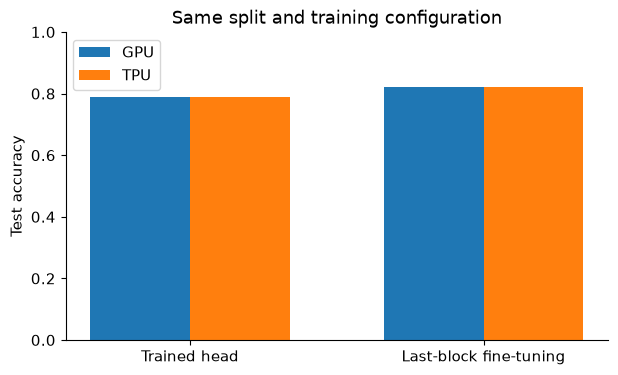

Trained head: GPU 79.0% / TPU 79.0%
Last-block fine-tuning: GPU 82.0% / TPU 82.0%
소수점 단위 차이는 있을 수 있습니다. 시간은 컴파일·캐시 조건에도 영향을 받으므로 여기서 속도의 우열을 정하지 않습니다.


In [ ]:
# GPU에서 회수한 report.json을 TPU 업로드 전에 results/gpu에 둡니다.
gpu_report_path = ROOT / "results/gpu/report.json"
if device.platform != "tpu":
    print("CPU 검증에서는 GPU/TPU를 비교하지 않습니다.")
elif not gpu_report_path.exists():
    print("GPU 결과가 없습니다. TPU 학습은 완료했습니다. GPU 결과를 업로드한 뒤 이 셀을 다시 실행할 수 있습니다.")
else:
    gpu_report = json.loads(gpu_report_path.read_text(encoding="utf-8"))
    checks = {
        "GPU 실행 완료": gpu_report.get("status") == "completed" and gpu_report["device"]["platform"] == "gpu",
        "모델 일치": gpu_report["model"] == report["model"],
        "데이터 일치": gpu_report["dataset"]["manifest_sha256"] == report["dataset"]["manifest_sha256"],
        "클래스 순서 일치": gpu_report["dataset"]["classes"] == report["dataset"]["classes"],
        "분할 ID 일치": gpu_report["dataset"]["split_ids"] == report["dataset"]["split_ids"],
    }
    comparison_keys = ["seed", "head_epochs", "finetune_epochs", "batch_size", "learning_rate",
                       "head_learning_rate", "dtype", "optimizer", "augmentation", "checkpoint_selection"]
    checks["학습 조건 일치"] = all(gpu_report["config"].get(key) == report["config"].get(key)
                                for key in comparison_keys)
    print(checks)
    if not all(checks.values()):
        print("조건이 달라 성능을 비교하지 않습니다. 원본 보고서를 확인하세요.")
    else:
        names = ["Trained head", "Last-block fine-tuning"]
        gpu_values = [gpu_report["stages"][stage]["test"]["accuracy"] for stage in ["head", "finetune"]]
        tpu_values = [report["stages"][stage]["test"]["accuracy"] for stage in ["head", "finetune"]]
        x = np.arange(2)
        fig, axis = plt.subplots(figsize=(7, 4))
        axis.bar(x - 0.17, gpu_values, width=0.34, label="GPU")
        axis.bar(x + 0.17, tpu_values, width=0.34, label="TPU")
        axis.set(xticks=x, xticklabels=names, ylim=(0, 1), ylabel="Test accuracy",
                 title="Same split and training configuration")
        axis.legend()
        plt.show()
        for name, gpu_value, tpu_value in zip(names, gpu_values, tpu_values):
            print(f"{name}: GPU {gpu_value:.1%} / TPU {tpu_value:.1%}")
        print("소수점 단위 차이는 있을 수 있습니다. 시간은 컴파일·캐시 조건에도 영향을 받으므로 여기서 속도의 우열을 정하지 않습니다.")